In [46]:
# STEP 1: IMPORT ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [47]:
# STEP 2: LOAD AND PREPARE DATA
# Load dataset
air_data = pd.read_csv('air_quality_health_dataset.csv')
air_data['date'] = pd.to_datetime(air_data['date'])

In [48]:
# Filter for East region only
air_data.set_index('date', inplace=True)
air_data = air_data[air_data['region'] == 'East']

In [49]:
# Select only the columns we need
air_data_east = air_data[['AQI', 'temperature', 'respiratory_admissions']]

In [50]:
# Remove duplicates and set daily frequency
air_data_east = air_data_east.reset_index()
air_data_east = air_data_east.drop_duplicates(subset='date')
air_data_east = air_data_east.set_index('date')
air_data_east = air_data_east.sort_index()
air_data_east = air_data_east.asfreq('D')
air_data_east = air_data_east.dropna()

print(" Data loaded successfully!")
print(f"Date range: {air_data_east.index.min()} to {air_data_east.index.max()}")
print(f"Total days: {len(air_data_east)}")
print(f"Columns: {air_data_east.columns.tolist()}")

 Data loaded successfully!
Date range: 2020-01-01 00:00:00 to 2021-12-30 00:00:00
Total days: 446
Columns: ['AQI', 'temperature', 'respiratory_admissions']


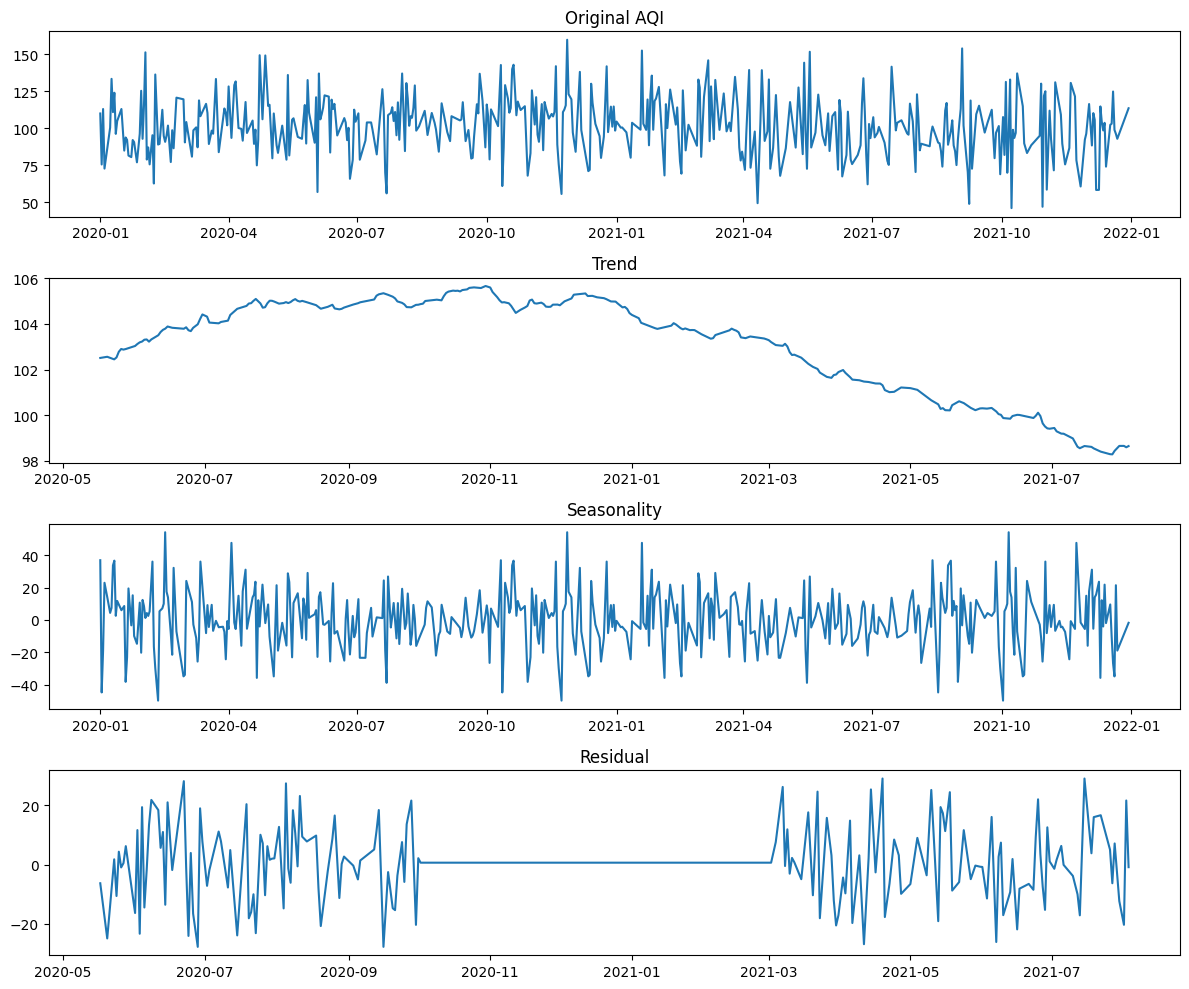

In [ ]:
# STEP 3: DECOMPOSITION FOR AQI (Trend + Seasonality + Residual)
decomp = seasonal_decompose(air_data_east['AQI'], model='additive', period=180)

plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(decomp.observed)
plt.title('Original AQI')

plt.subplot(4,1,2)
plt.plot(decomp.trend)
plt.title('Trend')

plt.subplot(4,1,3)
plt.plot(decomp.seasonal)
plt.title('Seasonality')

plt.subplot(4,1,4)
plt.plot(decomp.resid)
plt.title('Residual')

plt.tight_layout()
plt.show()

In [ ]:
# STEP 4: Forecasting - Exponential Smoothing
# Function to analyze AQI, Temperature and Respiratory_admissions
def analyze_variable(data, var_name):
    """
    Analyze any variable with ETS model
    """
    print(f"\n{'='*50}")
    print(f"Analyzing: {var_name}")
    print('='*50)
    
    # Get the data
    y = data[var_name].copy()
    
    # Split into train (2020) and test (2021)
    train = y['2020-01-01':'2020-12-31']
    test = y['2021-01-01':'2021-12-31']
    
    print(f"Train data: {len(train)} days (2020)")
    print(f"Test data: {len(test)} days (2021)")
    
    # ETS model
    model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=30).fit()
    forecast = model.forecast(len(test))
    
    # Calculating errors
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    
    print(f" MAE: {mae:.2f}")
    print(f" RMSE: {rmse:.2f}")
    
    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(train.index, train, label='Train (2020)', color='blue', linewidth=1)
    plt.plot(test.index, test, label='Actual (2021)', color='green', linewidth=1)
    plt.plot(test.index, forecast, label='ETS Forecast', color='red', linestyle='--', linewidth=1.5)
    plt.title(f'{var_name} - Forecast vs Actual (East Region)', fontsize=12)
    plt.xlabel('Date')
    plt.ylabel(var_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'variable': var_name, 'MAE': mae, 'RMSE': rmse}


In [ ]:
# STEP 5: Analyze all 3 variables
# List of variables to analyze
variables_to_analyze = ['AQI', 'temperature', 'respiratory_admissions']


Analyzing: AQI
Train data: 236 days (2020)
Test data: 210 days (2021)
 MAE: 20.28
 RMSE: 25.34


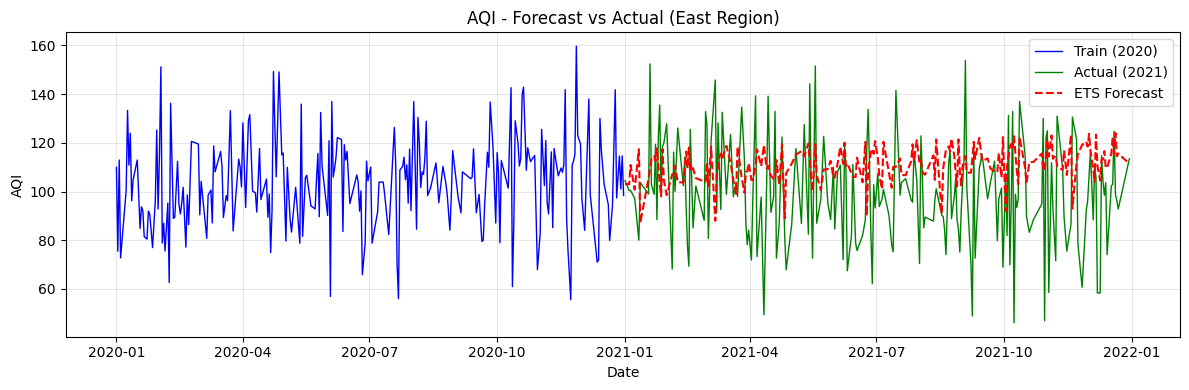


Analyzing: temperature
Train data: 236 days (2020)
Test data: 210 days (2021)
 MAE: 4.41
 RMSE: 5.35


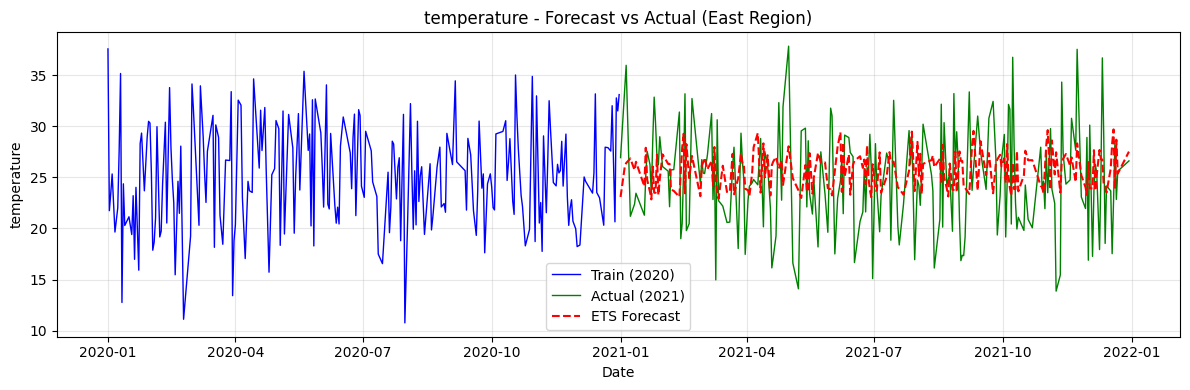


Analyzing: respiratory_admissions
Train data: 236 days (2020)
Test data: 210 days (2021)
 MAE: 2.56
 RMSE: 3.23


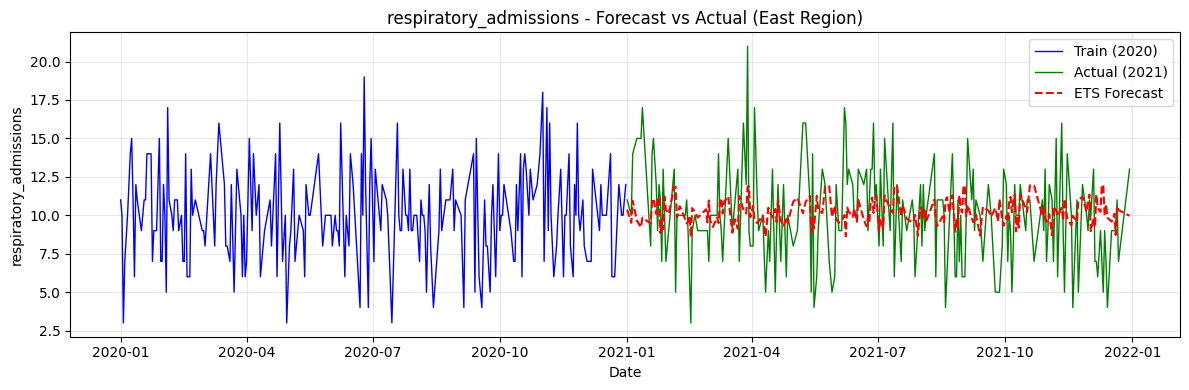

In [ ]:
# Store the results in all_results variable
all_results = []

# Run the analysis for each variable
for var in variables_to_analyze:
    result = analyze_variable(air_data_east, var)
    all_results.append(result)

In [ ]:
# STEP 6: COMPARING THE RESULTS
print("FINAL COMPARISON TABLE")

comparison_df = pd.DataFrame(all_results)
print(comparison_df.round(2))

FINAL COMPARISON TABLE
                 variable    MAE   RMSE
0                     AQI  20.28  25.34
1             temperature   4.41   5.35
2  respiratory_admissions   2.56   3.23


In [56]:
print("Analyzed:")
print("1. AQI")
print("2. Temperature")
print("3. Respiratory Hospital Admissions")

Analyzed:
1. AQI
2. Temperature
3. Respiratory Hospital Admissions
